# Customer Segmentation via Clustering — Consumer Shopping Behavior Survey

This notebook presents a complete end-to-end machine learning pipeline for unsupervised customer segmentation. The goal is to discover meaningful, data-driven customer groups from a shopping behavior survey dataset, enabling actionable marketing intelligence and personalization strategies.

**Pipeline Overview:**
1. Import Libraries
2. Load Dataset
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing and Feature Engineering
5. Dimensionality Reduction (PCA)
6. Optimal Cluster Selection
7. Hierarchical Clustering Dendrogram
8. Model Training (K-Means)
9. Model Evaluation
10. Cluster Profiling and Interpretation
11. Model Persistence
12. Inference Pipeline

---
## 1. Import Libraries

All dependencies are imported at the top for clarity and reproducibility. Standard scientific Python libraries are used alongside scikit-learn for modeling and scipy for hierarchical clustering.

In [12]:
import os
import warnings
import joblib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OrdinalEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    davies_bouldin_score,
    calinski_harabasz_score,
)
from sklearn.compose import ColumnTransformer
from scipy.cluster.hierarchy import dendrogram, linkage
from datetime import datetime

warnings.filterwarnings('ignore')
np.random.seed(42)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

RANDOM_STATE = 42

---
## 2. Load Dataset

The dataset is loaded from the local `Dataset` directory relative to this notebook. An initial inspection is performed to understand shape, dtypes, and data completeness.

In [13]:
DATA_PATH = '../Dataset/consumer_shopping_behavior_survey.csv'

df_raw = pd.read_csv(DATA_PATH)

print(f'Dataset Shape : {df_raw.shape}')
print(f'Rows          : {df_raw.shape[0]}')
print(f'Columns       : {df_raw.shape[1]}')
df_raw.head()

Dataset Shape : (500, 30)
Rows          : 500
Columns       : 30


,Response_ID,Timestamp,Age,Gender,Occupation_Status,Country_Region,Monthly_Income_Range,Shop_Most_Where,Online_Shopping_Frequency,Preferred_Platform,...,Return_Frequency,Avg_Monthly_Spend_NonEssentials,Preferred_Payment_Method,Uses_BNPL_Installments,Online_Shopping_Satisfaction_Score,Trust_In_Online_Reviews_Score,Regret_After_Purchase_Frequency,Reason_Prefer_Online,Reason_Prefer_InStore,Best_Shopping_Mode
0,1,01/08/2026 12:30:25,20,Male,NaN,Philippines,"Under $1,000",Equal mix,Often,Physical stores,...,Never,Under $50,Digital wallet,"Yes, occasionally",6.0,7.0,2.0,More variety,No delivery wait,Online
1,2,21/06/2026 13:52:02,24,Male,Employed part-time,Brazil,"Under $1,000",In-store only,Often,Local e-commerce,...,Often,Under $50,Digital wallet,"No, never",5.0,8.0,3.0,NaN,Try product before buying,Offline
2,3,15/08/2026 04:24:18,22,Female,Student,India,"Under $1,000",Equal mix,Always,Local e-commerce,...,Sometimes,$150-300,Credit Card,"No, never",7.0,6.0,2.0,Better prices,Trust,Online
3,4,23/06/2026 21:24:21,20,Male,Student,NaN,"Under $1,000",In-store only,Occasionally,Brand websites,...,Never,Under $50,Debit Card,"No, never",8.0,7.0,3.0,Better prices,Try product before buying,Equal / both
4,5,20/08/2026 16:24:47,41,Male,Employed full-time,United States,"$1,000-3,000",Equal mix,Occasionally,NaN,...,Sometimes,$50-150,Debit Card,"No, never",6.0,8.0,2.0,Convenience,Trust,Equal / both


In [14]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 30 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Response_ID                         500 non-null    int64  
 1   Timestamp                           500 non-null    str    
 2   Age                                 478 non-null    str    
 3   Gender                              484 non-null    str    
 4   Occupation_Status                   479 non-null    str    
 5   Country_Region                      480 non-null    str    
 6   Monthly_Income_Range                479 non-null    str    
 7   Shop_Most_Where                     484 non-null    str    
 8   Online_Shopping_Frequency           481 non-null    str    
 9   Preferred_Platform                  486 non-null    str    
 10  Primary_Device                      492 non-null    str    
 11  Top_Spending_Category               476 non-null    str 

In [15]:
df_raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Response_ID,500.0,NaN,NaN,NaN,250.5,144.481833,1.0,125.75,250.5,375.25,500.0
Timestamp,500,500,01/08/2026 12:30:25,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,478,43,21,67,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,484,3,Male,256,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Occupation_Status,479,5,Student,238,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country_Region,480,18,India,66,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Monthly_Income_Range,479,4,"Under $1,000",257,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Shop_Most_Where,484,3,Equal mix,248,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Online_Shopping_Frequency,481,4,Occasionally,240,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Preferred_Platform,486,4,Global marketplace (Amazon etc.),141,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## 3. Exploratory Data Analysis (EDA)

Before preprocessing, a thorough visual and statistical exploration is conducted to:
- Identify missing values and their distribution
- Understand the distribution of numeric behavioral scores
- Explore categorical feature cardinality
- Detect potential correlations among numeric score features

In [16]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing (%)', ascending=False)

print('Columns with Missing Values:')
print(missing_df.to_string())

Columns with Missing Values:
                                    Missing Count  Missing (%)
Reason_Prefer_Online                           54         10.8
Regret_After_Purchase_Frequency                52         10.4
Best_Shopping_Mode                             51         10.2
Trust_In_Online_Reviews_Score                  50         10.0
Reason_Prefer_InStore                          45          9.0
Online_Shopping_Satisfaction_Score             43          8.6
Price_Comparison_Frequency                     26          5.2
Likely_To_Buy_After_Ad_Score                   25          5.0
Top_Spending_Category                          24          4.8
Makes_Shopping_List                            24          4.8
Discount_Importance_Score                      23          4.6
Age                                            22          4.4
Occupation_Status                              21          4.2
Monthly_Income_Range                           21          4.2
Social_Ads_Influence_Score

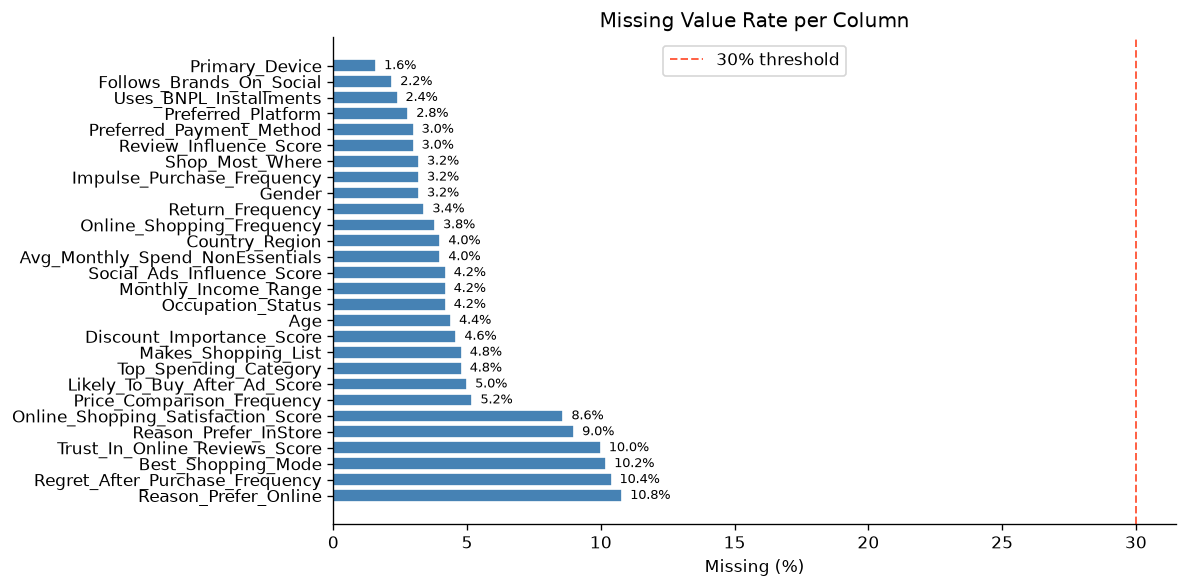

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(missing_df.index, missing_df['Missing (%)'], color='steelblue', edgecolor='white')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Value Rate per Column')
ax.axvline(x=30, color='tomato', linestyle='--', linewidth=1.2, label='30% threshold')
ax.legend()
for bar, val in zip(bars, missing_df['Missing (%)']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2, f'{val}%', va='center', fontsize=8)
plt.tight_layout()
plt.show()

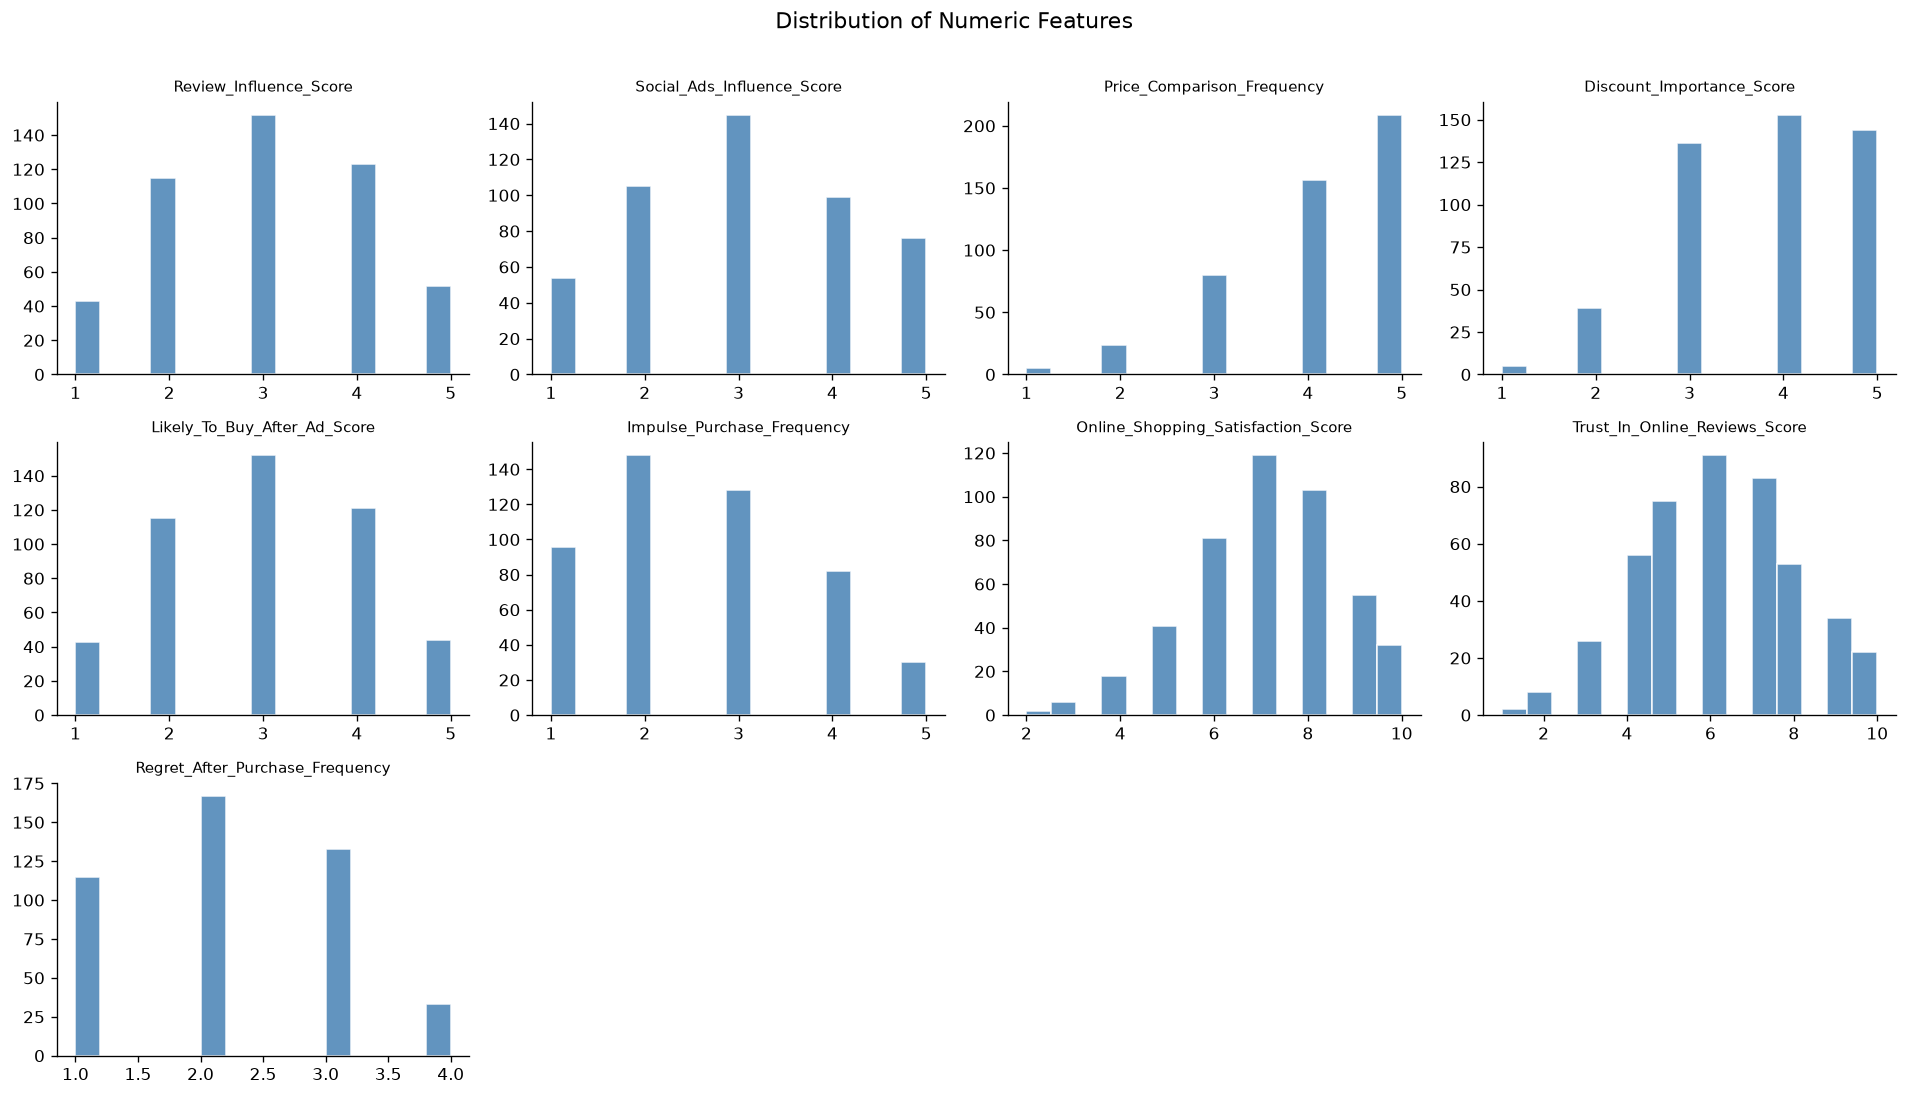

In [18]:
numeric_cols = [c for c in df_raw.select_dtypes(include=[np.number]).columns if c != 'Response_ID']

n_c = 4
n_r = -(-len(numeric_cols) // n_c)
fig, axes = plt.subplots(n_r, n_c, figsize=(16, n_r * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df_raw[col].dropna(), bins=15, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=9)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Numeric Features', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

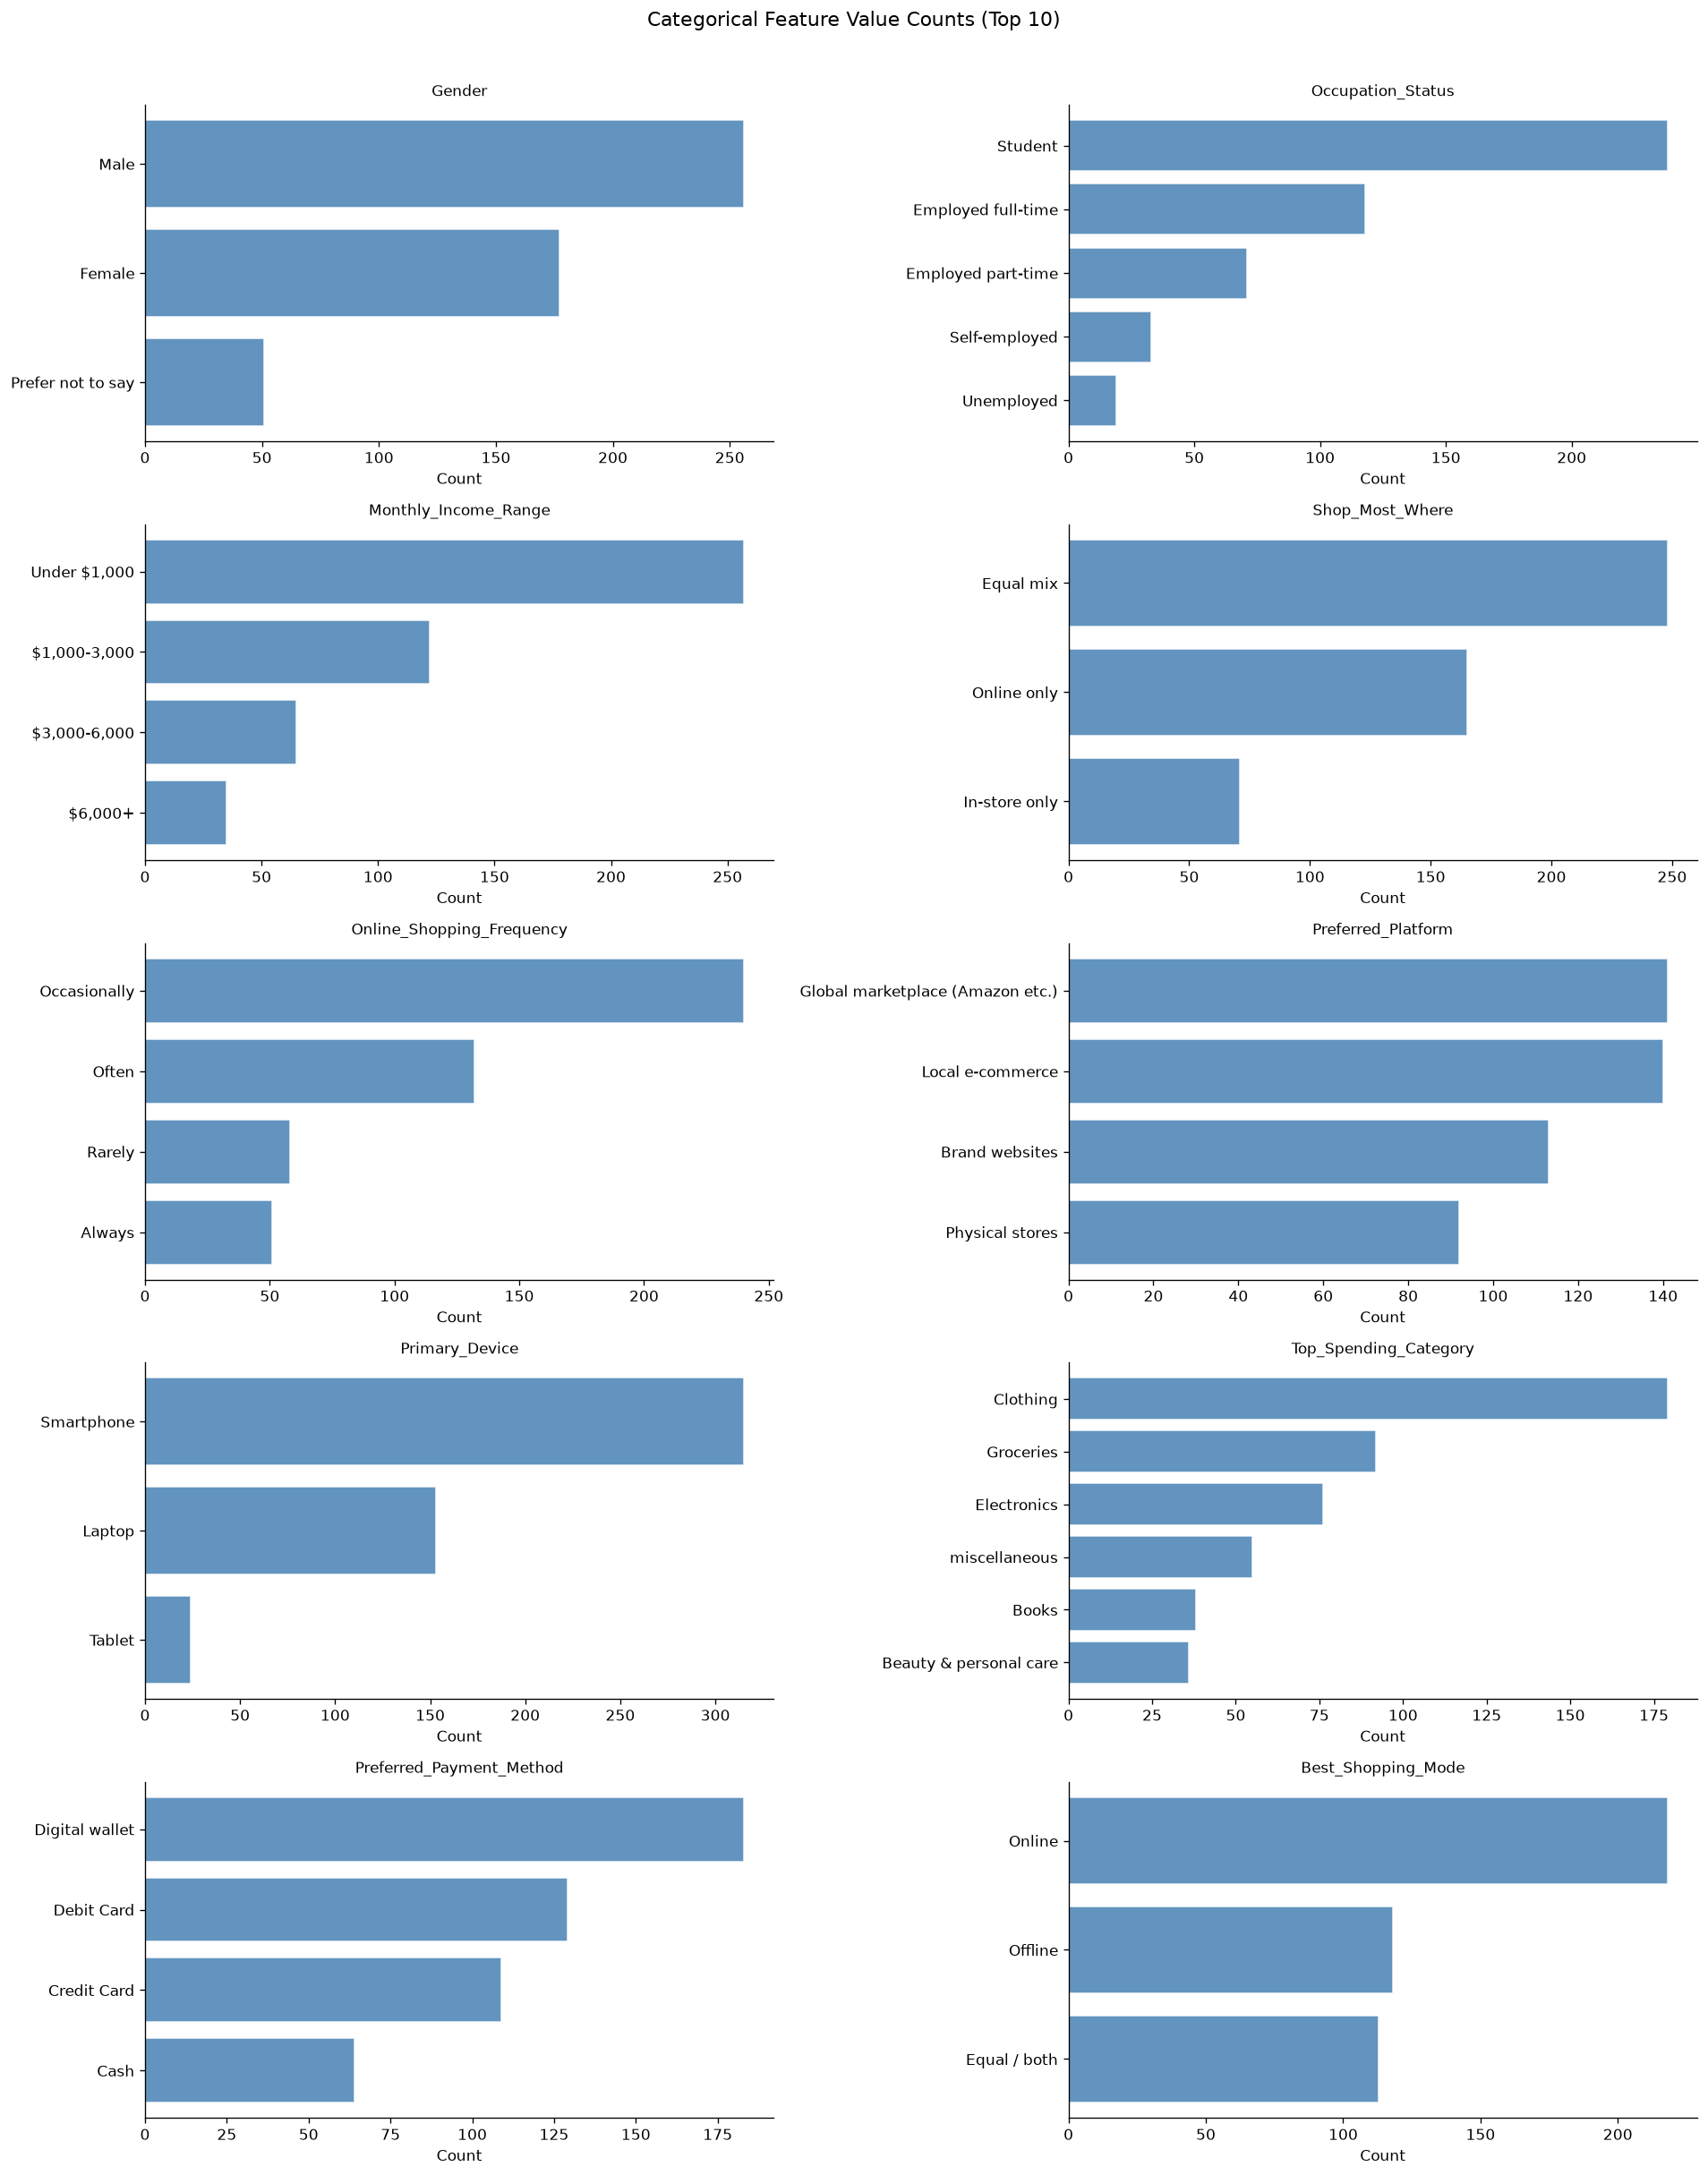

In [19]:
cat_cols_eda = [
    'Gender', 'Occupation_Status', 'Monthly_Income_Range', 'Shop_Most_Where',
    'Online_Shopping_Frequency', 'Preferred_Platform', 'Primary_Device',
    'Top_Spending_Category', 'Preferred_Payment_Method', 'Best_Shopping_Mode'
]

n_c2 = 2
n_r2 = -(-len(cat_cols_eda) // n_c2)
fig, axes = plt.subplots(n_r2, n_c2, figsize=(16, n_r2 * 4))
axes = axes.flatten()

for i, col in enumerate(cat_cols_eda):
    counts = df_raw[col].value_counts().head(10)
    axes[i].barh(counts.index[::-1], counts.values[::-1], color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('Count')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Feature Value Counts (Top 10)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

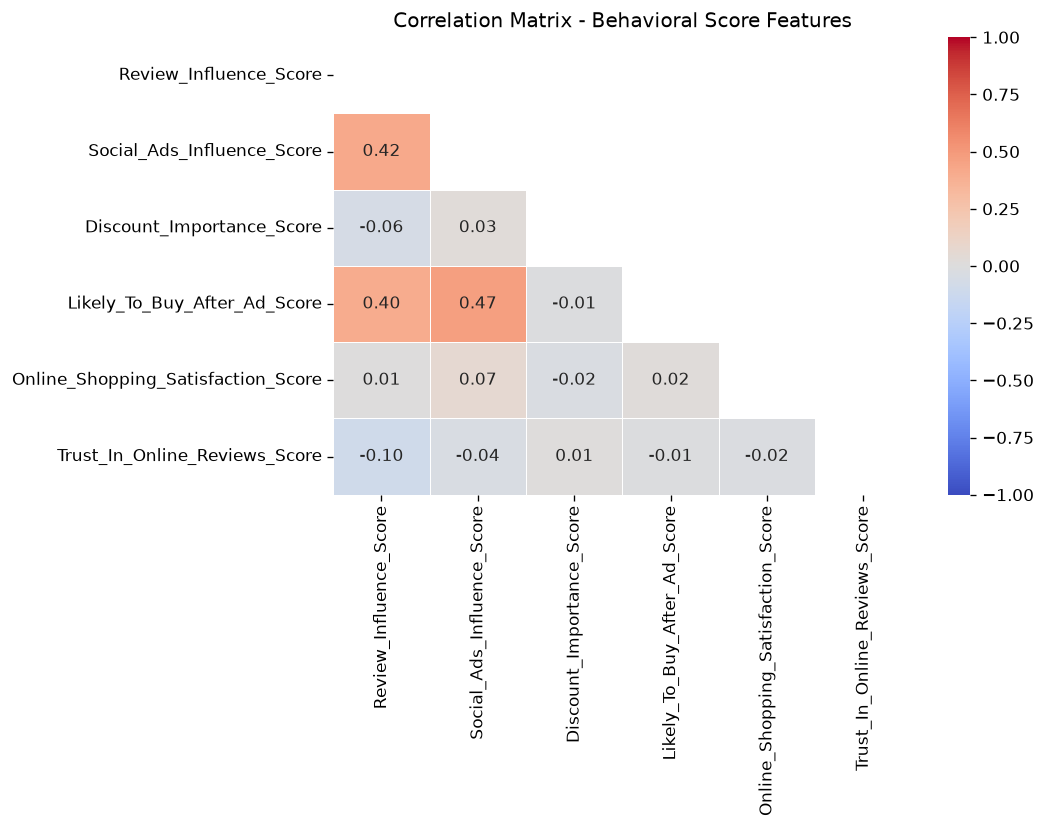

In [20]:
score_cols = [
    'Review_Influence_Score', 'Social_Ads_Influence_Score', 'Discount_Importance_Score',
    'Likely_To_Buy_After_Ad_Score', 'Online_Shopping_Satisfaction_Score', 'Trust_In_Online_Reviews_Score'
]

corr_matrix = df_raw[score_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Matrix - Behavioral Score Features', fontsize=12)
plt.tight_layout()
plt.show()

---
## 4. Data Preprocessing and Feature Engineering

### Feature Selection Strategy

Columns that carry no behavioral signal (`Response_ID`, `Timestamp`) are dropped. Features are split into three groups:

- **Numeric:** Directly usable after imputation and scaling.
- **Ordinal Categorical:** Variables with a natural ordering (e.g., income range, shopping frequency).
- **Nominal Categorical:** Variables without inherent order, encoded with OrdinalEncoder.

### Ordinal Encoding Maps

Ordinal features are encoded using domain-defined rank orders before scaling. This preserves the semantic ordering, for example `Rarely < Occasionally < Often < Always`.

### Imputation Strategy

- Numeric features: imputed with the **median** (robust to skew and outliers).
- Categorical features: imputed with the **most frequent** value.

In [21]:
DROP_COLS = ['Response_ID', 'Timestamp']
df = df_raw.drop(columns=DROP_COLS, errors='ignore').copy()

NUMERIC_FEATURES = [
    'Age',
    'Review_Influence_Score',
    'Social_Ads_Influence_Score',
    'Price_Comparison_Frequency',
    'Discount_Importance_Score',
    'Likely_To_Buy_After_Ad_Score',
    'Impulse_Purchase_Frequency',
    'Online_Shopping_Satisfaction_Score',
    'Trust_In_Online_Reviews_Score',
    'Regret_After_Purchase_Frequency',
]

ORDINAL_FEATURES = [
    'Monthly_Income_Range',
    'Online_Shopping_Frequency',
    'Avg_Monthly_Spend_NonEssentials',
    'Uses_BNPL_Installments',
]

NOMINAL_FEATURES = [
    'Gender',
    'Occupation_Status',
    'Country_Region',
    'Shop_Most_Where',
    'Preferred_Platform',
    'Primary_Device',
    'Top_Spending_Category',
    'Preferred_Payment_Method',
    'Makes_Shopping_List',
    'Follows_Brands_On_Social',
    'Reason_Prefer_Online',
    'Reason_Prefer_InStore',
    'Best_Shopping_Mode',
    'Return_Frequency',
]

ORDINAL_CATEGORIES = {
    'Monthly_Income_Range': ['Under $1,000', '$1,000-3,000', '$3,000-6,000', '$6,000+'],
    'Online_Shopping_Frequency': ['Rarely', 'Occasionally', 'Often', 'Always'],
    'Avg_Monthly_Spend_NonEssentials': ['Under $50', '$50-150', '$150-300', '$300-500', '$500+'],
    'Uses_BNPL_Installments': ['No, never', 'Yes, occasionally', 'Yes, regularly'],
}

df_features = df[NUMERIC_FEATURES + ORDINAL_FEATURES + NOMINAL_FEATURES].copy()
print(f'Feature matrix shape: {df_features.shape}')

Feature matrix shape: (500, 28)


In [22]:
numeric_transformer = Pipeline(steps=[
    ('coerce', FunctionTransformer(
        lambda X: pd.DataFrame(X).apply(pd.to_numeric, errors='coerce').values,
        validate=False,
    )),
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        categories=[ORDINAL_CATEGORIES[f] for f in ORDINAL_FEATURES],
        handle_unknown='use_encoded_value',
        unknown_value=-1,
    )),
    ('scaler', StandardScaler()),
])

nominal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        handle_unknown='use_encoded_value',
        unknown_value=-1,
    )),
    ('scaler', StandardScaler()),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', numeric_transformer, NUMERIC_FEATURES),
        ('ordinal', ordinal_transformer, ORDINAL_FEATURES),
        ('nominal', nominal_transformer, NOMINAL_FEATURES),
    ],
    remainder='drop',
)

X_processed = preprocessor.fit_transform(df_features)
print(f'Processed feature matrix shape: {X_processed.shape}')

Processed feature matrix shape: (500, 28)


---
## 5. Dimensionality Reduction with PCA

Principal Component Analysis (PCA) is applied for two purposes:

1. **Noise reduction:** Retaining components that explain 90% of cumulative variance removes low-signal dimensions.
2. **Visualization:** A 2D projection allows direct visual inspection of cluster separability.

PCA is fit on the preprocessed feature matrix and the explained variance ratio is analyzed via a scree plot.

Components needed to explain 90% variance: 23


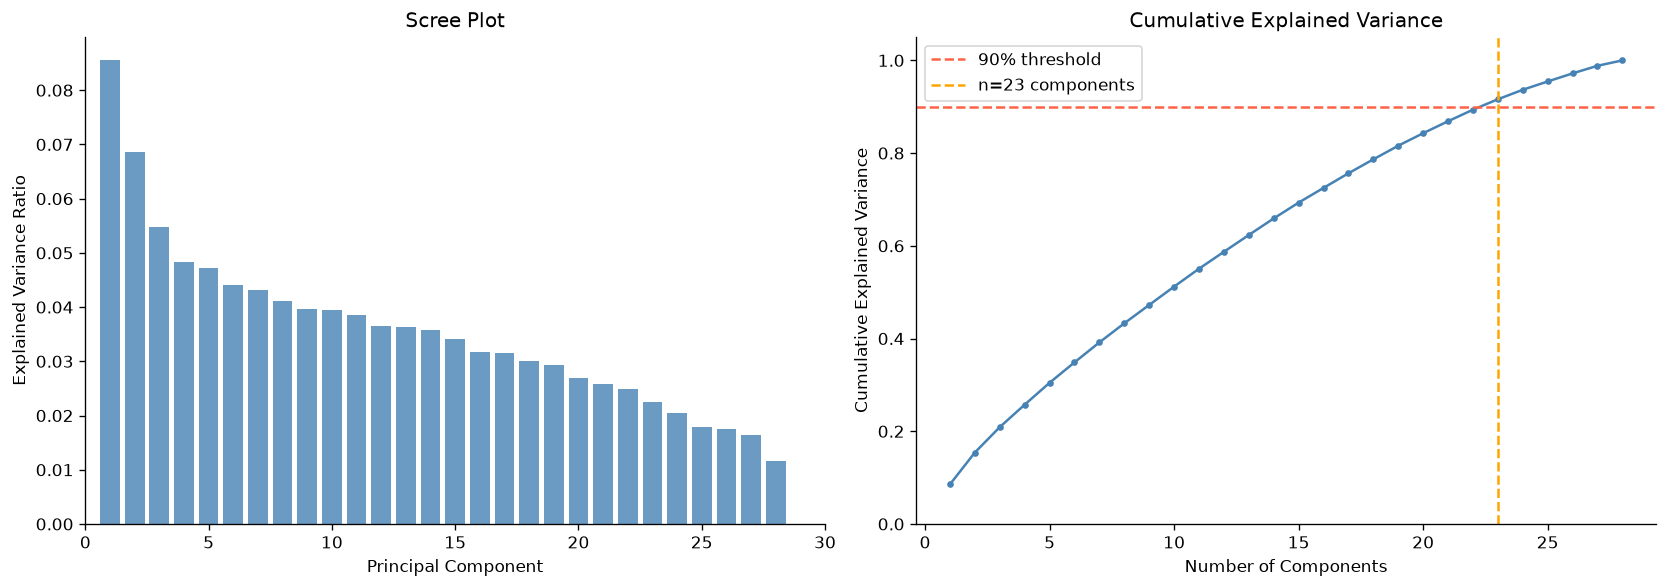

In [23]:
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_processed)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components_90 = int(np.argmax(cumulative_variance >= 0.90)) + 1

print(f'Components needed to explain 90% variance: {n_components_90}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
            pca_full.explained_variance_ratio_, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot')
axes[0].set_xlim([0, 30])

axes[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance,
             marker='o', markersize=3, color='steelblue')
axes[1].axhline(y=0.90, color='tomato', linestyle='--', label='90% threshold')
axes[1].axvline(x=n_components_90, color='orange', linestyle='--',
                label=f'n={n_components_90} components')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()
axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

In [24]:
pca_model = PCA(n_components=n_components_90, random_state=RANDOM_STATE)
X_pca = pca_model.fit_transform(X_processed)

pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca_2d.fit_transform(X_processed)

print(f'PCA reduced matrix shape         : {X_pca.shape}')
print(f'Total explained variance retained: {pca_model.explained_variance_ratio_.sum():.4f}')

PCA reduced matrix shape         : (500, 23)
Total explained variance retained: 0.9161


---
## 6. Optimal Number of Clusters

Four complementary methods are used to determine the ideal value of k:

- **Elbow Method:** Plots inertia (within-cluster sum of squares) against k. The optimal k sits at the inflection point where the rate of decrease slows.
- **Silhouette Score:** Measures cohesion versus separation for each sample (range -1 to 1, higher is better).
- **Davies-Bouldin Index:** Evaluates the ratio of within-cluster scatter to between-cluster separation (lower is better).
- **Calinski-Harabasz Score:** Ratio of between-cluster to within-cluster dispersion (higher is better).

The final k is chosen based on convergent evidence across all four metrics.

In [25]:
K_RANGE = range(2, 12)

inertia_list, silhouette_list, db_list, ch_list = [], [], [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=20, max_iter=500, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_pca)
    inertia_list.append(km.inertia_)
    silhouette_list.append(silhouette_score(X_pca, labels))
    db_list.append(davies_bouldin_score(X_pca, labels))
    ch_list.append(calinski_harabasz_score(X_pca, labels))

metrics_df = pd.DataFrame({
    'k': list(K_RANGE),
    'Inertia': inertia_list,
    'Silhouette': silhouette_list,
    'Davies-Bouldin': db_list,
    'Calinski-Harabasz': ch_list,
})

print(metrics_df.to_string(index=False))

 k      Inertia  Silhouette  Davies-Bouldin  Calinski-Harabasz
 2 11974.933300    0.068699        3.640995          35.358849
 3 11421.976367    0.055662        3.492251          30.528395
 4 11097.065046    0.051833        3.362469          25.746809
 5 10837.444625    0.046362        3.307292          22.697372
 6 10588.728994    0.046756        3.306580          20.867544
 7 10430.598828    0.045861        3.237618          18.863180
 8 10285.704852    0.042732        3.157983          17.353055
 9 10170.546946    0.040879        3.075114          16.019565
10 10029.923771    0.041546        2.992006          15.173181
11  9920.982698    0.043197        3.124041          14.314606


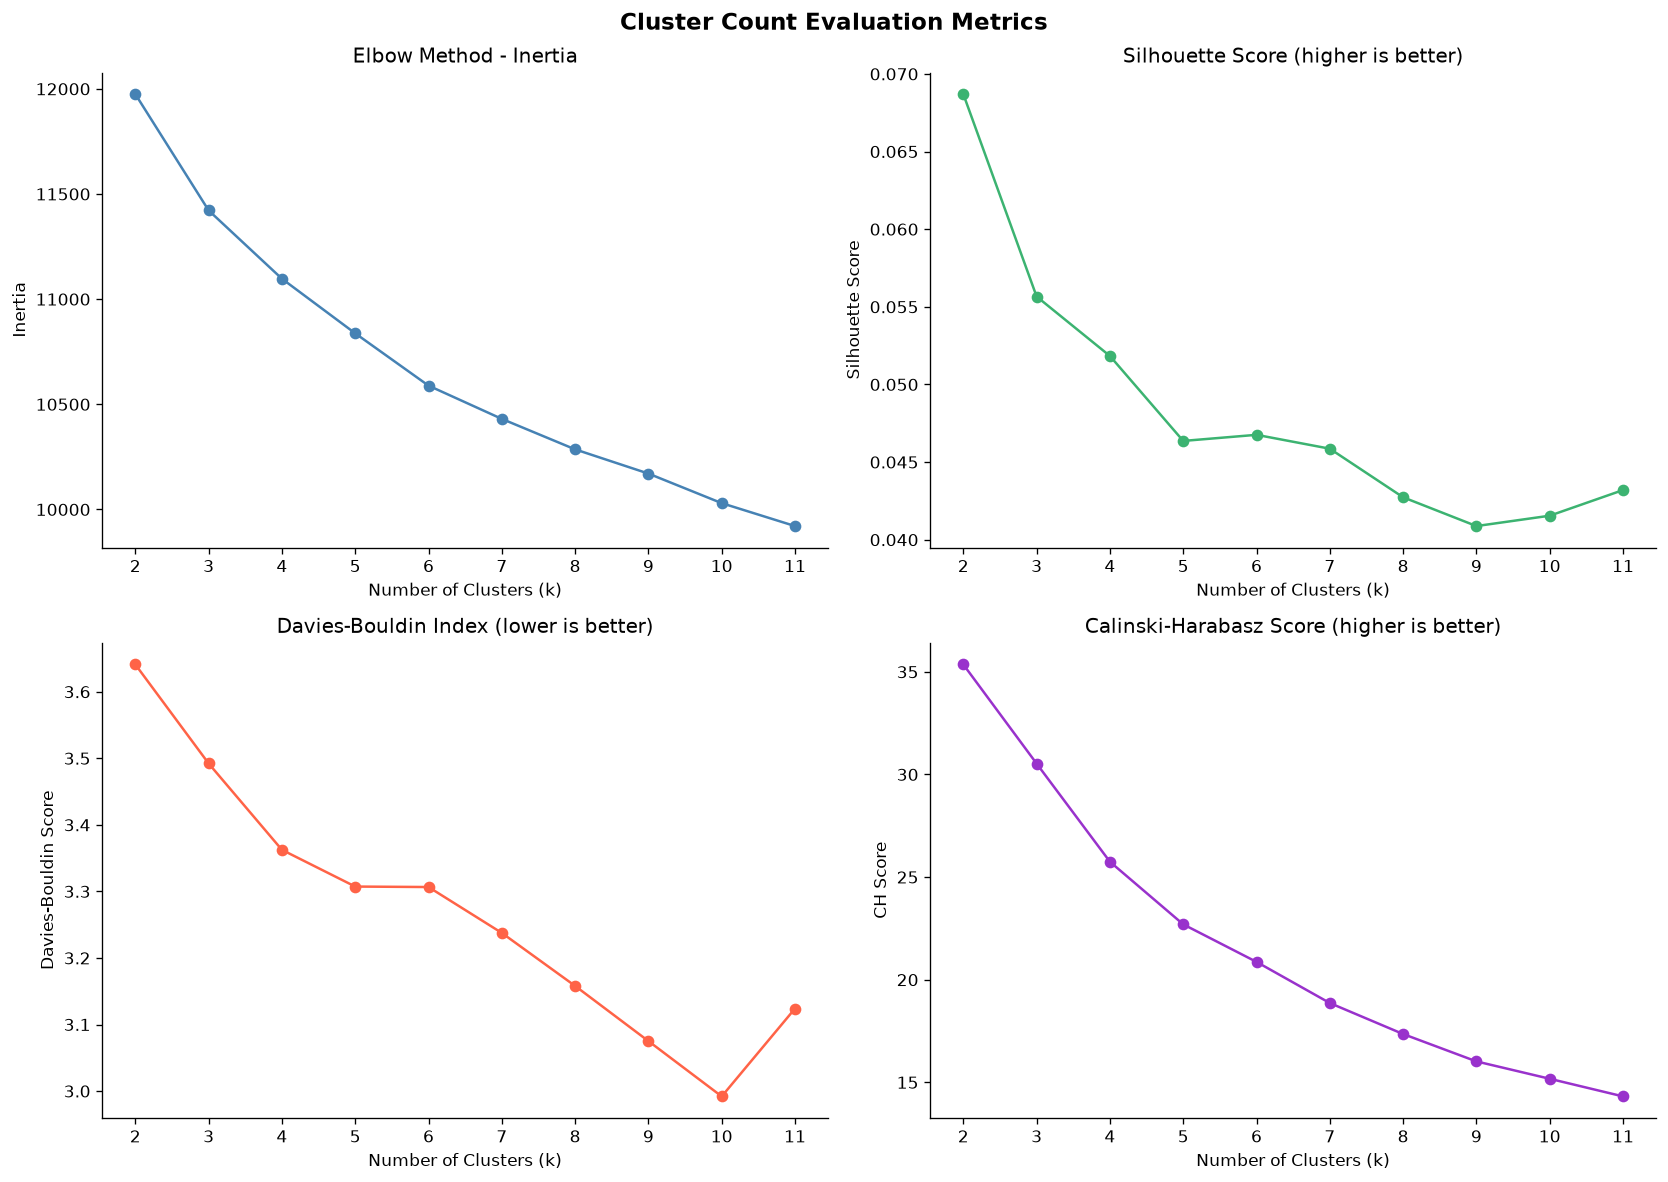

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(metrics_df['k'], metrics_df['Inertia'], marker='o', color='steelblue')
axes[0, 0].set_title('Elbow Method - Inertia')
axes[0, 0].set_xlabel('Number of Clusters (k)')
axes[0, 0].set_ylabel('Inertia')

axes[0, 1].plot(metrics_df['k'], metrics_df['Silhouette'], marker='o', color='mediumseagreen')
axes[0, 1].set_title('Silhouette Score (higher is better)')
axes[0, 1].set_xlabel('Number of Clusters (k)')
axes[0, 1].set_ylabel('Silhouette Score')

axes[1, 0].plot(metrics_df['k'], metrics_df['Davies-Bouldin'], marker='o', color='tomato')
axes[1, 0].set_title('Davies-Bouldin Index (lower is better)')
axes[1, 0].set_xlabel('Number of Clusters (k)')
axes[1, 0].set_ylabel('Davies-Bouldin Score')

axes[1, 1].plot(metrics_df['k'], metrics_df['Calinski-Harabasz'], marker='o', color='darkorchid')
axes[1, 1].set_title('Calinski-Harabasz Score (higher is better)')
axes[1, 1].set_xlabel('Number of Clusters (k)')
axes[1, 1].set_ylabel('CH Score')

for ax in axes.flatten():
    ax.set_xticks(list(K_RANGE))

plt.suptitle('Cluster Count Evaluation Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [27]:
OPTIMAL_K = int(metrics_df.loc[metrics_df['Silhouette'].idxmax(), 'k'])
best_sil = metrics_df.loc[metrics_df['k'] == OPTIMAL_K, 'Silhouette'].values[0]
print(f'Optimal number of clusters (highest Silhouette Score): k = {OPTIMAL_K}')
print(f'Silhouette Score at k={OPTIMAL_K}: {best_sil:.4f}')

Optimal number of clusters (highest Silhouette Score): k = 2
Silhouette Score at k=2: 0.0687


---
## 7. Hierarchical Clustering - Dendrogram

A Ward linkage dendrogram is generated as secondary validation. The dendrogram reveals the hierarchical merging structure and confirms the optimal k by identifying the largest vertical gap between successive merge distances.

A random sample of 200 records is used to keep the visualization readable.

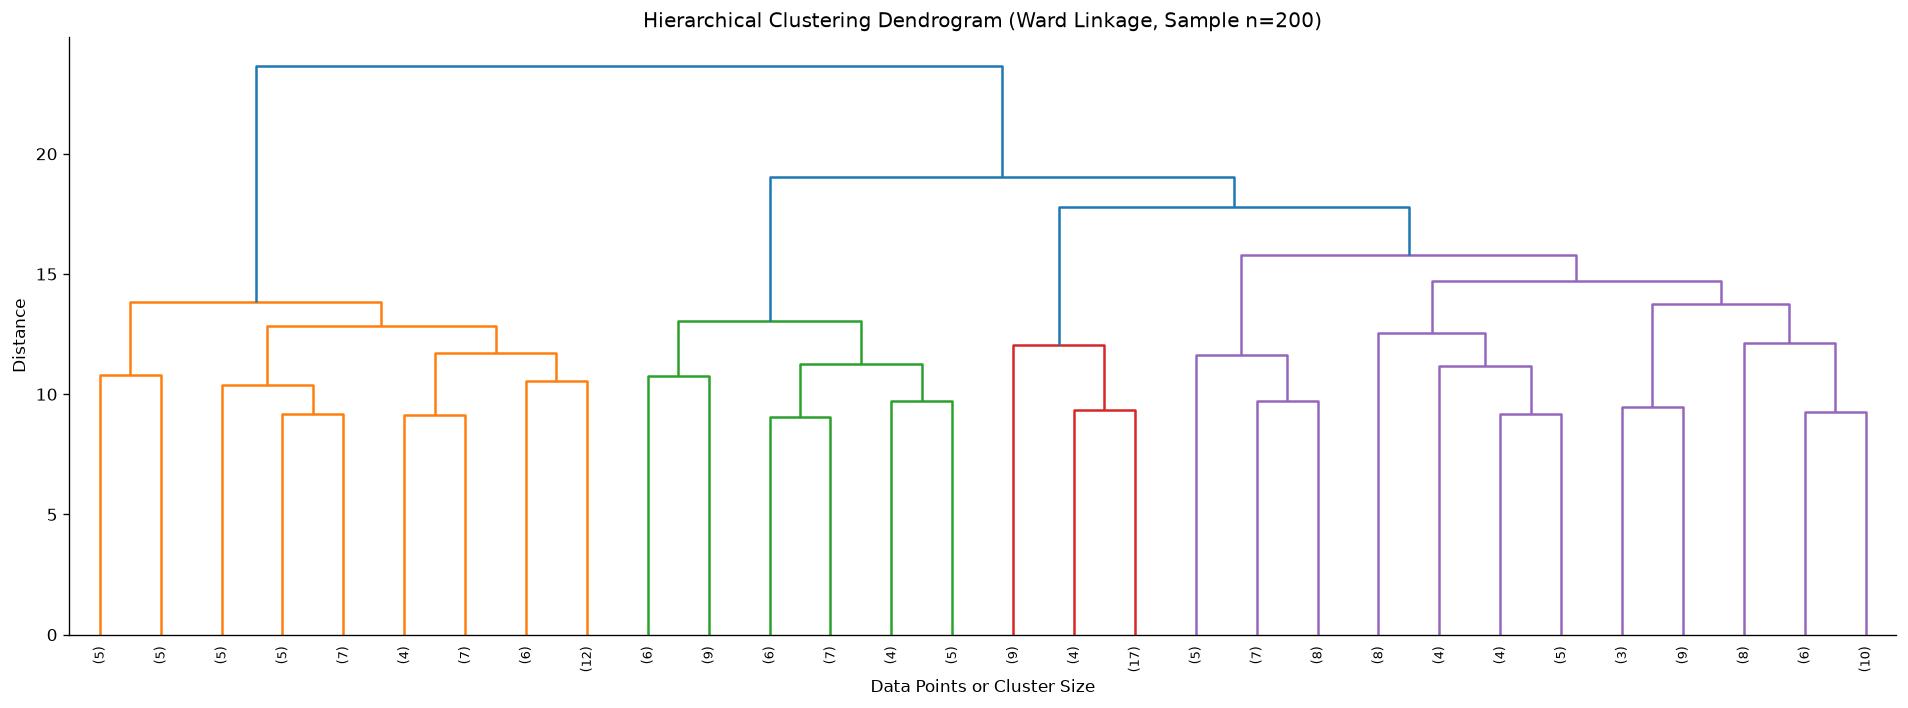

In [28]:
sample_idx = np.random.choice(len(X_pca), size=min(200, len(X_pca)), replace=False)
X_sample = X_pca[sample_idx]

linkage_matrix = linkage(X_sample, method='ward')

fig, ax = plt.subplots(figsize=(16, 6))
dendrogram(
    linkage_matrix,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=8,
    ax=ax,
    color_threshold=0.7 * max(linkage_matrix[:, 2]),
)
ax.set_title('Hierarchical Clustering Dendrogram (Ward Linkage, Sample n=200)', fontsize=12)
ax.set_xlabel('Data Points or Cluster Size')
ax.set_ylabel('Distance')
plt.tight_layout()
plt.show()

---
## 8. Model Training - K-Means Clustering

The final K-Means model is trained using the optimal k determined in the previous step.

**Hyperparameter choices:**
- `init='k-means++'`: Smart centroid initialization to accelerate convergence and avoid poor local minima.
- `n_init=50`: Runs the algorithm 50 times with different centroid seeds; the best run (lowest inertia) is kept.
- `max_iter=500`: Upper bound on iterations per run.

Cluster labels are appended back to the original dataframe for subsequent profiling.

In [29]:
kmeans_final = KMeans(
    n_clusters=OPTIMAL_K,
    init='k-means++',
    n_init=50,
    max_iter=500,
    random_state=RANDOM_STATE,
)

cluster_labels = kmeans_final.fit_predict(X_pca)

df['Cluster'] = cluster_labels
df_features['Cluster'] = cluster_labels

print('Cluster distribution:')
cluster_counts = df['Cluster'].value_counts().sort_index()
for cluster, count in cluster_counts.items():
    print(f'  Cluster {cluster}: {count} customers ({count / len(df) * 100:.1f}%)')

Cluster distribution:
  Cluster 0: 194 customers (38.8%)
  Cluster 1: 306 customers (61.2%)


---
## 9. Model Evaluation

### Internal Validation Metrics

Since clustering is unsupervised (no ground truth labels exist), evaluation relies on internal validation indices.

| Metric | Interpretation |
|---|---|
| Silhouette Score | Cohesion vs. separation; range -1 to 1, higher is better |
| Davies-Bouldin Index | Average similarity to the most similar cluster; lower is better |
| Calinski-Harabasz Score | Ratio of between/within scatter; higher is better |
| Inertia | Sum of squared distances to centroids; lower means tighter clusters |

### Silhouette Plot

The silhouette plot visualizes the silhouette coefficient for each sample within each cluster. Wide positive bars indicate well-separated, cohesive clusters. Negative coefficients indicate samples that may have been assigned to the wrong cluster.

In [30]:
sil_score = silhouette_score(X_pca, cluster_labels)
db_score  = davies_bouldin_score(X_pca, cluster_labels)
ch_score  = calinski_harabasz_score(X_pca, cluster_labels)
inertia   = kmeans_final.inertia_

print('=== Final Model Evaluation Metrics ===')
print(f'  Silhouette Score     : {sil_score:.4f}  (range -1 to 1, higher is better)')
print(f'  Davies-Bouldin Index : {db_score:.4f}  (lower is better)')
print(f'  Calinski-Harabasz    : {ch_score:.2f}  (higher is better)')
print(f'  Inertia              : {inertia:.4f}')
print(f'  Number of Clusters   : {OPTIMAL_K}')

=== Final Model Evaluation Metrics ===
  Silhouette Score     : 0.0687  (range -1 to 1, higher is better)
  Davies-Bouldin Index : 3.6410  (lower is better)
  Calinski-Harabasz    : 35.36  (higher is better)
  Inertia              : 11974.9333
  Number of Clusters   : 2


AttributeError: module 'matplotlib.cm' has no attribute 'get_cmap'

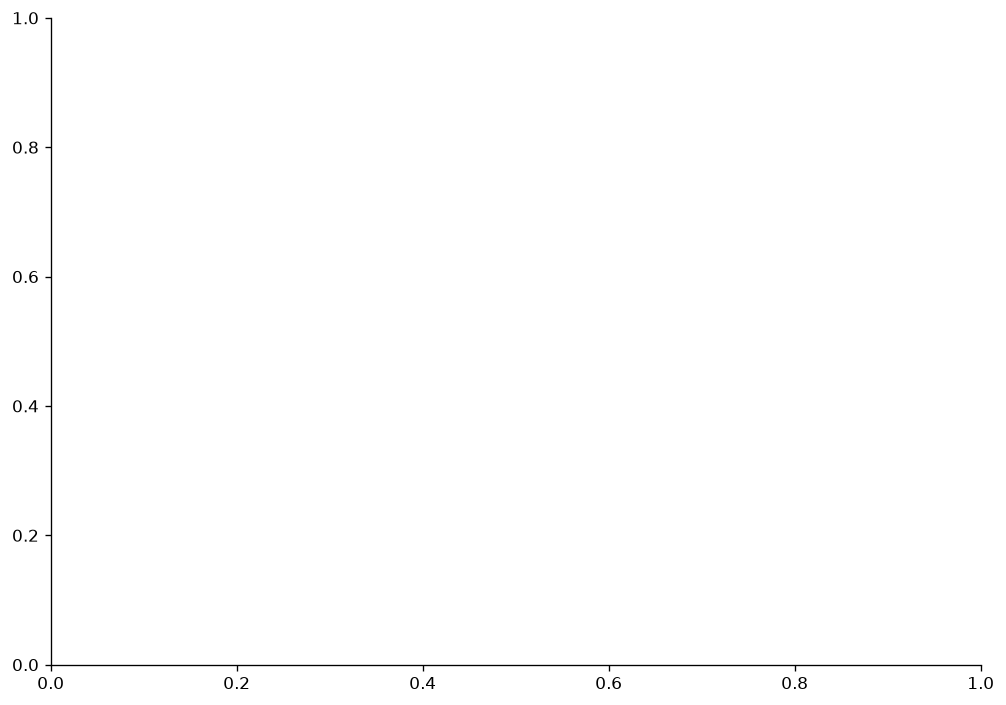

In [31]:
sil_samples = silhouette_samples(X_pca, cluster_labels)

fig, ax = plt.subplots(figsize=(10, 7))
y_lower = 10
colors_map = plt.get_cmap('tab10', OPTIMAL_K)

for i in range(OPTIMAL_K):
    ith_sil = np.sort(sil_samples[cluster_labels == i])
    size_i = ith_sil.shape[0]
    y_upper = y_lower + size_i
    color = colors_map(i)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_sil,
                     facecolor=color, edgecolor=color, alpha=0.75)
    ax.text(-0.05, y_lower + 0.5 * size_i, str(i), fontsize=9)
    y_lower = y_upper + 10

ax.axvline(x=sil_score, color='tomato', linestyle='--',
           label=f'Average Silhouette = {sil_score:.3f}')
ax.set_title(f'Silhouette Plot for K-Means (k={OPTIMAL_K})', fontsize=13)
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')
ax.set_yticks([])
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))
colors_map = plt.get_cmap('tab10', OPTIMAL_K)

for i in range(OPTIMAL_K):
    mask_c = cluster_labels == i
    ax.scatter(X_2d[mask_c, 0], X_2d[mask_c, 1],
               c=[colors_map(i)], label=f'Cluster {i}',
               s=30, alpha=0.65, edgecolors='white', linewidths=0.3)

ax.set_title('2D PCA Projection - Cluster Assignments', fontsize=13)
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.legend(title='Cluster', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

---
## 10. Cluster Profiling and Interpretation

Each cluster is profiled along key behavioral dimensions to extract actionable insights. The analysis covers:

- Mean numeric feature values per cluster (normalized heatmap)
- Dominant categorical value per cluster for key demographic and behavioral features
- Stacked bar proportions of categorical features across clusters
- Cluster size comparison (bar chart and pie chart)

In [ ]:
profile_numeric = [
    'Age', 'Review_Influence_Score', 'Social_Ads_Influence_Score',
    'Discount_Importance_Score', 'Likely_To_Buy_After_Ad_Score',
    'Impulse_Purchase_Frequency', 'Online_Shopping_Satisfaction_Score',
    'Trust_In_Online_Reviews_Score'
]

cluster_profile = df.groupby('Cluster')[profile_numeric].mean().round(2)
cluster_profile

In [ ]:
fig, ax = plt.subplots(figsize=(13, 6))
profile_norm = (cluster_profile - cluster_profile.min()) / (cluster_profile.max() - cluster_profile.min())
im = ax.imshow(profile_norm.T, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(OPTIMAL_K))
ax.set_xticklabels([f'Cluster {i}' for i in range(OPTIMAL_K)], fontsize=10)
ax.set_yticks(range(len(profile_numeric)))
ax.set_yticklabels(profile_numeric, fontsize=9)
ax.set_title('Cluster Profile Heatmap (Normalized Mean Values)', fontsize=12)
plt.colorbar(im, ax=ax, label='Normalized Value')
for i in range(OPTIMAL_K):
    for j in range(len(profile_numeric)):
        ax.text(i, j, f'{cluster_profile.iloc[i, j]:.1f}',
                ha='center', va='center', fontsize=8, color='black')
plt.tight_layout()
plt.show()

In [ ]:
profile_cat = [
    'Gender', 'Occupation_Status', 'Monthly_Income_Range',
    'Top_Spending_Category', 'Best_Shopping_Mode', 'Preferred_Payment_Method'
]

print('=== Dominant Categorical Value per Cluster ===')
for cat in profile_cat:
    if cat in df.columns:
        print(f'\n{cat}:')
        dominant = df.groupby('Cluster')[cat].agg(
            lambda x: x.value_counts().idxmax() if x.notna().any() else 'N/A'
        )
        for c, v in dominant.items():
            print(f'  Cluster {c}: {v}')

In [ ]:
n_cat = len(profile_cat)
n_cols_p = 3
n_rows_p = -(-n_cat // n_cols_p)

fig, axes = plt.subplots(n_rows_p, n_cols_p, figsize=(16, n_rows_p * 5))
axes = axes.flatten()

for idx, cat in enumerate(profile_cat):
    if cat not in df.columns:
        continue
    pivot = df.groupby(['Cluster', cat]).size().unstack(fill_value=0)
    pivot = pivot.div(pivot.sum(axis=1), axis=0)
    pivot.plot(kind='bar', ax=axes[idx], colormap='tab20', edgecolor='white', legend=True)
    axes[idx].set_title(cat, fontsize=10)
    axes[idx].set_xlabel('Cluster')
    axes[idx].set_ylabel('Proportion')
    axes[idx].tick_params(axis='x', rotation=0)
    axes[idx].legend(fontsize=7, loc='upper right')

for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Feature Distribution per Cluster', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
cluster_sizes = df['Cluster'].value_counts().sort_index()
colors_map = plt.get_cmap('tab10', OPTIMAL_K)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

axes[0].bar(
    [f'Cluster {i}' for i in cluster_sizes.index],
    cluster_sizes.values,
    color=[colors_map(i) for i in range(OPTIMAL_K)],
    edgecolor='white',
)
axes[0].set_title('Cluster Size Distribution')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(cluster_sizes.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontsize=10)

axes[1].pie(
    cluster_sizes.values,
    labels=[f'Cluster {i}' for i in cluster_sizes.index],
    colors=[colors_map(i) for i in range(OPTIMAL_K)],
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.82,
)
axes[1].set_title('Cluster Size Proportion')

plt.suptitle('Cluster Size Overview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
print('=== Cluster Summary Statistics ===')
summary = df.groupby('Cluster')[profile_numeric].agg(['mean', 'std']).round(2)
summary

---
## 11. Model Persistence

All model artifacts are serialized and saved to the `Model/artifacts/` directory. This ensures the pipeline can be fully reproduced and deployed without retraining.

| Artifact | Filename | Description |
|---|---|---|
| Preprocessor | `preprocessor.joblib` | Fitted ColumnTransformer (imputer + encoder + scaler) |
| PCA Model | `pca_model.joblib` | Fitted PCA for dimensionality reduction |
| K-Means Model | `kmeans_model.joblib` | Fitted K-Means clustering model |
| Cluster Profiles | `cluster_profiles.csv` | Mean numeric profile per cluster |
| Model Metadata | `model_metadata.json` | Hyperparameters, metrics, and feature lists |
| Labeled Dataset | `df_with_clusters.csv` | Original data enriched with cluster labels |

In [ ]:
ARTIFACTS_DIR = './artifacts'
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

joblib.dump(preprocessor, os.path.join(ARTIFACTS_DIR, 'preprocessor.joblib'))
joblib.dump(pca_model,    os.path.join(ARTIFACTS_DIR, 'pca_model.joblib'))
joblib.dump(kmeans_final, os.path.join(ARTIFACTS_DIR, 'kmeans_model.joblib'))

cluster_profile.to_csv(os.path.join(ARTIFACTS_DIR, 'cluster_profiles.csv'))
df.to_csv(os.path.join(ARTIFACTS_DIR, 'df_with_clusters.csv'), index=False)

metadata = {
    'model_name': 'KMeans Customer Segmentation',
    'trained_at': datetime.now().isoformat(),
    'n_clusters': OPTIMAL_K,
    'n_pca_components': n_components_90,
    'pca_explained_variance': float(pca_model.explained_variance_ratio_.sum()),
    'silhouette_score': float(sil_score),
    'davies_bouldin_score': float(db_score),
    'calinski_harabasz_score': float(ch_score),
    'inertia': float(inertia),
    'n_samples_trained': int(X_pca.shape[0]),
    'features': {
        'numeric': NUMERIC_FEATURES,
        'ordinal': ORDINAL_FEATURES,
        'nominal': NOMINAL_FEATURES,
    },
    'hyperparameters': {
        'init': 'k-means++',
        'n_init': 50,
        'max_iter': 500,
        'random_state': RANDOM_STATE,
    },
}

with open(os.path.join(ARTIFACTS_DIR, 'model_metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=4)

print('All model artifacts saved successfully.')
print(f'Artifacts directory: {os.path.abspath(ARTIFACTS_DIR)}')
for fname in sorted(os.listdir(ARTIFACTS_DIR)):
    fpath = os.path.join(ARTIFACTS_DIR, fname)
    size_kb = os.path.getsize(fpath) / 1024
    print(f'  {fname:45s} {size_kb:7.2f} KB')

---
## 12. Inference Pipeline

The inference pipeline loads all persisted artifacts and accepts new raw customer records. Given a new customer survey response, the pipeline:

1. Structures the input as a single-row DataFrame with the same feature columns used during training.
2. Applies the fitted preprocessor (imputation, encoding, scaling) without data leakage.
3. Reduces dimensionality using the fitted PCA.
4. Assigns the customer to a cluster using the fitted K-Means model.
5. Returns the cluster label along with the matching cluster behavioral profile.

This design guarantees complete reproducibility and eliminates training-serving skew.

In [ ]:
loaded_preprocessor = joblib.load(os.path.join(ARTIFACTS_DIR, 'preprocessor.joblib'))
loaded_pca          = joblib.load(os.path.join(ARTIFACTS_DIR, 'pca_model.joblib'))
loaded_kmeans       = joblib.load(os.path.join(ARTIFACTS_DIR, 'kmeans_model.joblib'))
loaded_profiles     = pd.read_csv(os.path.join(ARTIFACTS_DIR, 'cluster_profiles.csv'), index_col='Cluster')

with open(os.path.join(ARTIFACTS_DIR, 'model_metadata.json'), 'r') as f:
    loaded_metadata = json.load(f)

print('Artifacts loaded successfully.')
print(f"  Model     : {loaded_metadata['model_name']}")
print(f"  Clusters  : {loaded_metadata['n_clusters']}")
print(f"  Trained at: {loaded_metadata['trained_at']}")

In [ ]:
def predict_cluster(raw_customer_record: dict) -> dict:
    """
    Predict the cluster assignment for a new customer record.

    Parameters
    ----------
    raw_customer_record : dict
        A dictionary mapping feature names to their raw values,
        exactly as they appear in the original survey CSV.

    Returns
    -------
    dict
        Contains 'cluster_id' (int), 'cluster_profile' (pd.Series),
        and 'input_df' (pd.DataFrame of the input record).
    """
    feature_order = (
        loaded_metadata['features']['numeric']
        + loaded_metadata['features']['ordinal']
        + loaded_metadata['features']['nominal']
    )

    input_df   = pd.DataFrame([raw_customer_record], columns=feature_order)
    X_proc     = loaded_preprocessor.transform(input_df)
    X_reduced  = loaded_pca.transform(X_proc)
    cluster_id = int(loaded_kmeans.predict(X_reduced)[0])
    profile    = loaded_profiles.loc[cluster_id]

    return {'cluster_id': cluster_id, 'cluster_profile': profile, 'input_df': input_df}

In [ ]:
new_customer = {
    'Age': 27,
    'Review_Influence_Score': 4,
    'Social_Ads_Influence_Score': 5,
    'Price_Comparison_Frequency': 4,
    'Discount_Importance_Score': 5,
    'Likely_To_Buy_After_Ad_Score': 4,
    'Impulse_Purchase_Frequency': 3,
    'Return_Frequency': 2,
    'Online_Shopping_Satisfaction_Score': 7,
    'Trust_In_Online_Reviews_Score': 6,
    'Regret_After_Purchase_Frequency': 2,
    'Monthly_Income_Range': '$1,000-3,000',
    'Online_Shopping_Frequency': 'Often',
    'Avg_Monthly_Spend_NonEssentials': '$50-150',
    'Uses_BNPL_Installments': 'Yes, occasionally',
    'Gender': 'Female',
    'Occupation_Status': 'Employed full-time',
    'Country_Region': 'Indonesia',
    'Shop_Most_Where': 'Online only',
    'Preferred_Platform': 'Global marketplace (Amazon etc.)',
    'Primary_Device': 'Smartphone',
    'Top_Spending_Category': 'Clothing',
    'Preferred_Payment_Method': 'Digital wallet',
    'Makes_Shopping_List': 'Sometimes',
    'Follows_Brands_On_Social': 'Yes',
    'Reason_Prefer_Online': 'Better prices',
    'Reason_Prefer_InStore': 'Try product before buying',
    'Best_Shopping_Mode': 'Online',
}

result = predict_cluster(new_customer)

print(f"Predicted Cluster ID : {result['cluster_id']}")
print('\nCluster Profile (Mean Numeric Features):')
print(result['cluster_profile'].to_string())

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

profile_vals = result['cluster_profile'].values
profile_cols = result['cluster_profile'].index.tolist()
median_val   = np.median(profile_vals)

bar_colors = ['tomato' if v >= median_val else 'steelblue' for v in profile_vals]
bars = ax.bar(range(len(profile_cols)), profile_vals, color=bar_colors, edgecolor='white', alpha=0.85)

ax.set_xticks(range(len(profile_cols)))
ax.set_xticklabels(profile_cols, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Mean Score')
ax.set_title(f"Cluster {result['cluster_id']} Profile - Inferred Customer Segment", fontsize=12)

for bar, val in zip(bars, profile_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f'{val:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nNew customer successfully assigned to Cluster {result['cluster_id']}.")

---
## Summary

This notebook built a complete, production-ready customer segmentation pipeline on the Consumer Shopping Behavior Survey dataset.

**What was accomplished:**

- A robust preprocessing pipeline handles mixed data types (numeric, ordinal, nominal) with domain-informed encoding and median/mode imputation.
- PCA reduces noise and computational cost while retaining the majority of variance in the feature space.
- The optimal cluster count was determined through convergent evidence from four internal validation metrics.
- Each discovered cluster represents a distinct customer archetype with unique behavioral, demographic, and spending patterns.
- All model artifacts are serialized for deployment, and the inference function accepts raw survey records and returns the cluster assignment with its corresponding profile.

**Potential next steps:**

- Validate cluster stability with bootstrapped resampling or cross-validation analogues.
- Experiment with alternative algorithms such as DBSCAN or Gaussian Mixture Models to assess robustness.
- Build a customer-facing segment report with actionable marketing recommendations per cluster.
- Integrate the inference pipeline into a REST API or recommendation engine for real-time scoring.